In [ ]:
import os
import re

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import differential_evolution, nnls
import torch

from core.data import load_dataset, split_dataset, CLASS_TO_IDX
from core.utils import seed_everything, make_generator

plt.rcParams.update({'legend.fontsize': 8,
                     'axes.titlesize': 10})
os.chdir(os.path.dirname(os.path.abspath('pinn.ipynb')))

In [2]:
# params
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else 'cpu')
REGION = ['mouth', 'nose']
SEED = 0
NUM_EPOCHS = 500
BATCH_SIZE = 16
LR = 1e-3 
BETA_MAX = 0.1
LAMBDA_SPARSITY = 0.001
LAMBDA_BASELINE = 1.0
TAU_S = 15.0
CKPT_PATH = 'results/pinn/best_checkpoint.pt'
os.makedirs('results/pinn', exist_ok=True)

# reproducibility
seed_everything(SEED)
g = make_generator(SEED)

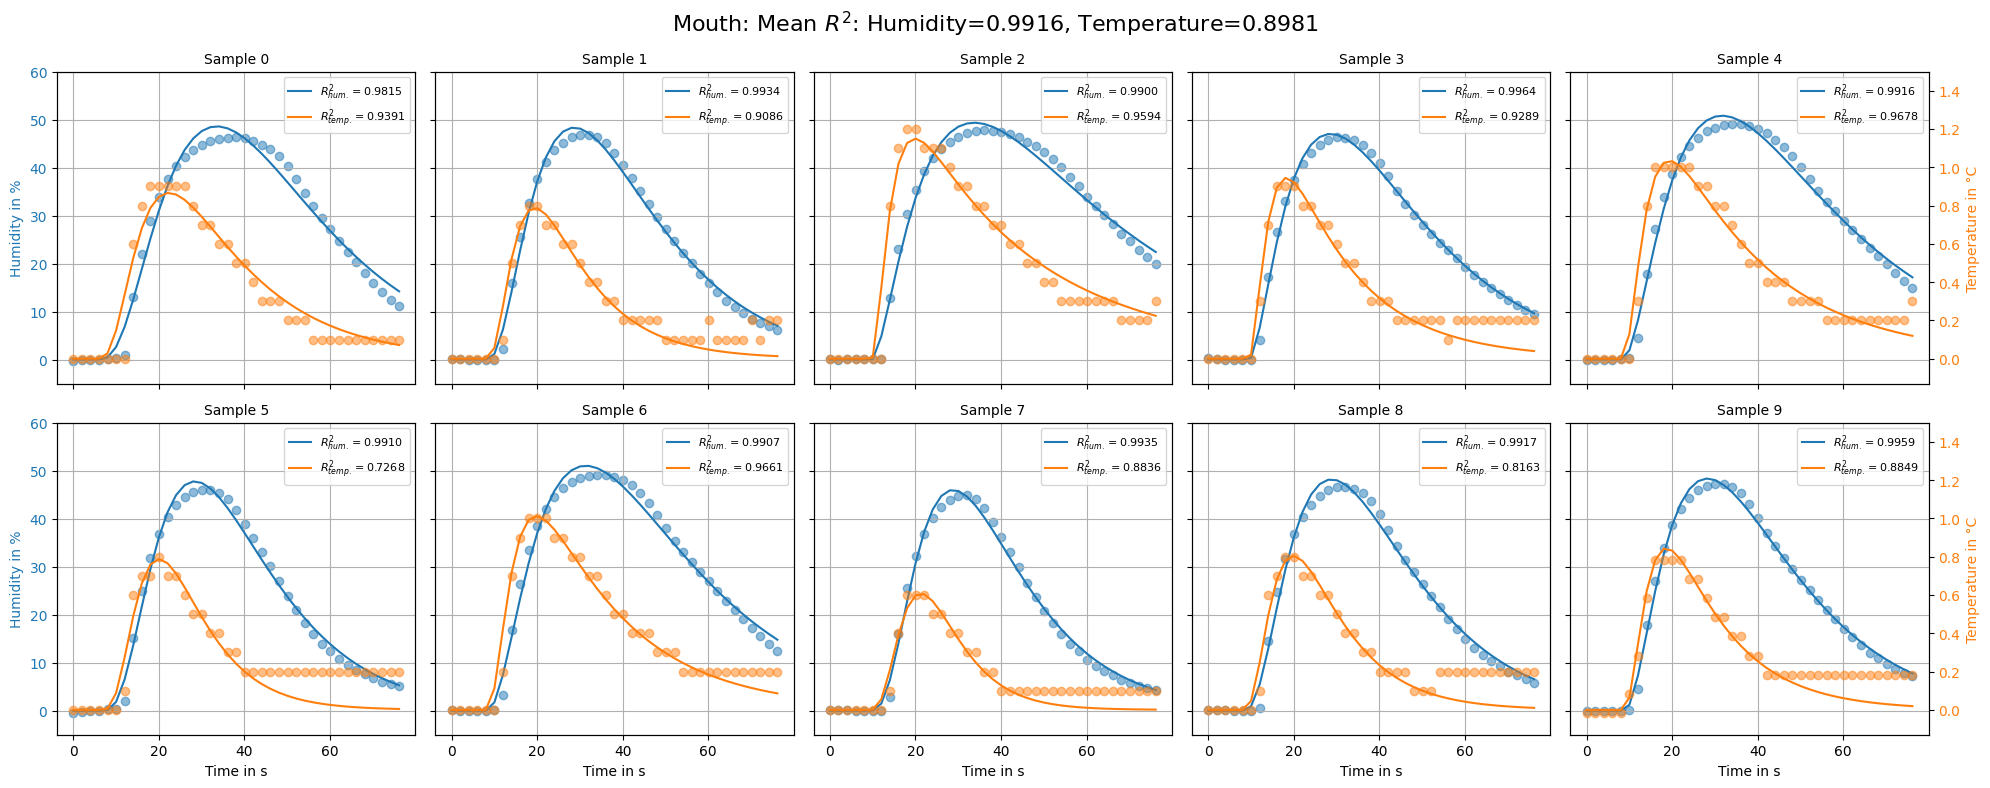

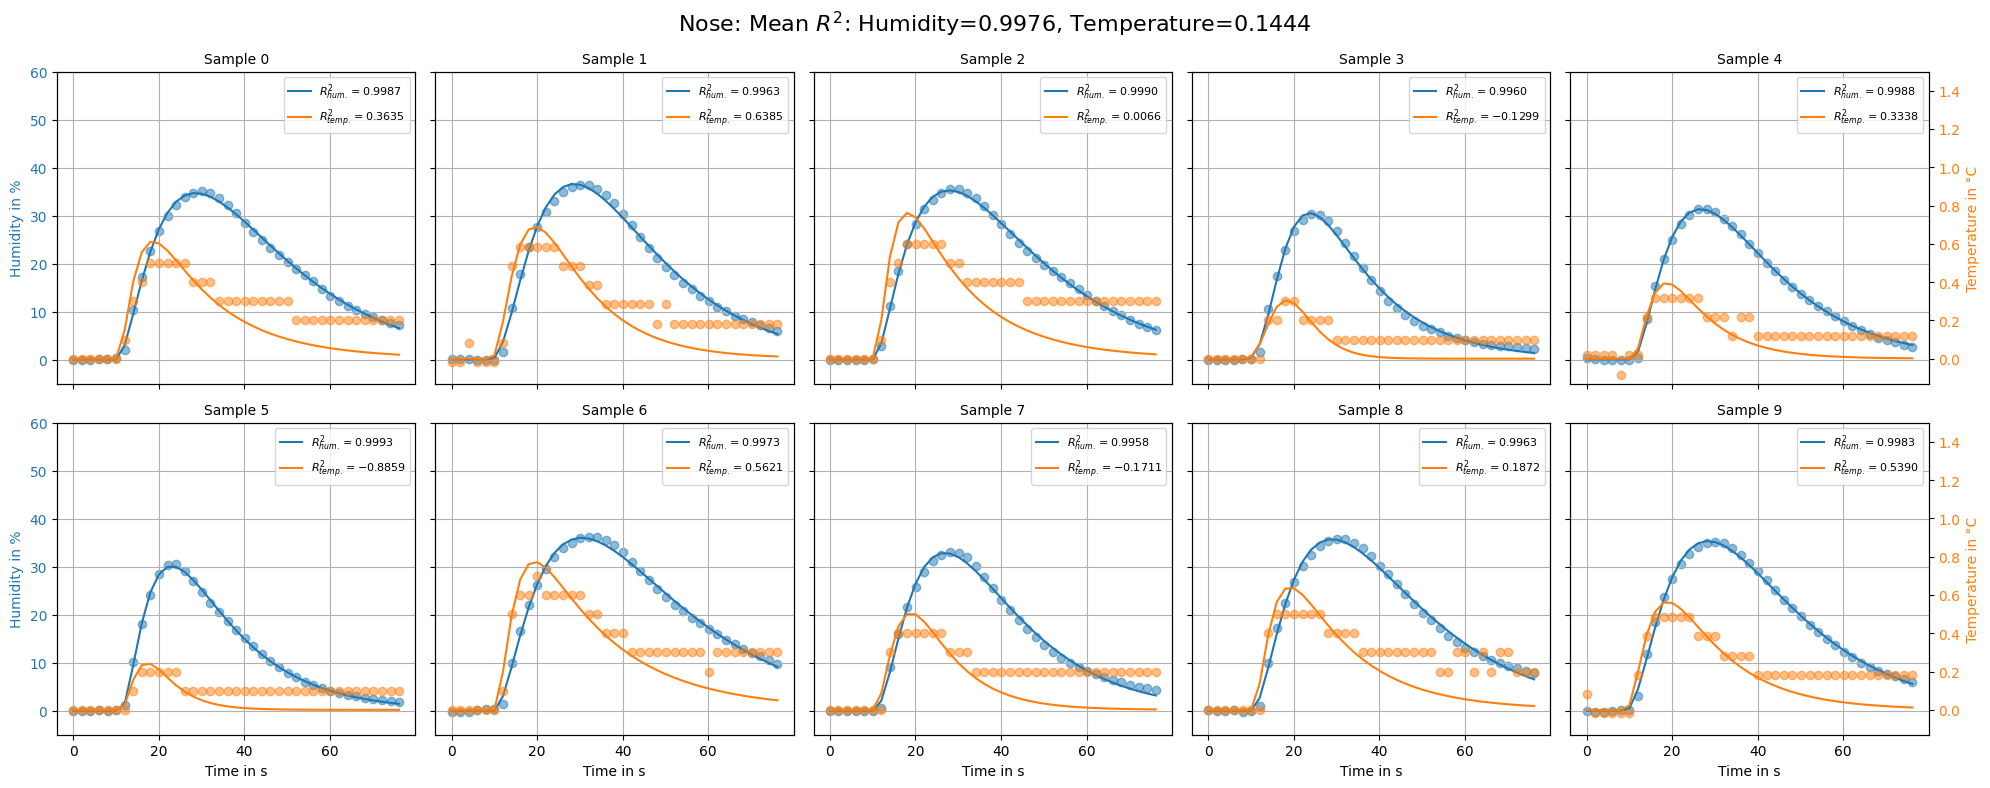

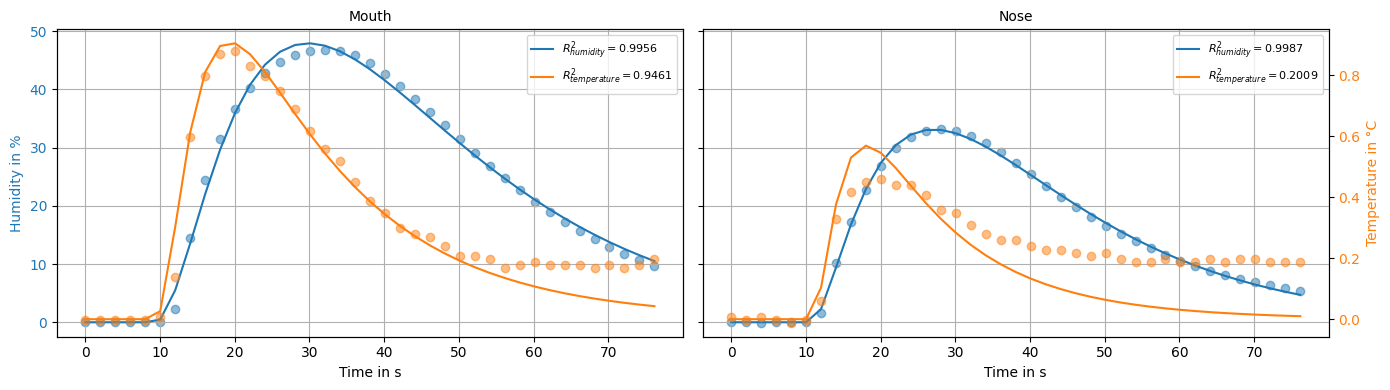


MOUTH
Fit then Mean
Humidity   : A=4.7635 ± 1.0018, D=1.99e-05 ± 1.06e-05, v=0.0020 ± 0.0003, t_shift=5.0483 ± 1.6251
Temperature: A=0.0877 ± 0.0339, D=1.99e-05 ± 1.06e-05, v=0.0020 ± 0.0003, t_shift=5.0483 ± 1.6251
Mean R^2   : Humidity=0.9916, Temperature=0.8981

Mean then Fit
Humidity   : A=5.2581, D=2.51e-05, v=0.0023, t_shift=6.3434
Temperature: A=0.0960, D=2.51e-05, v=0.0023, t_shift=6.3434
R^2        : Humidity=0.9956, Temperature=0.9461

NOSE
Fit then Mean
Humidity   : A=3.8579 ± 0.7125, D=2.64e-05 ± 1.03e-05, v=0.0028 ± 0.0006, t_shift=6.9399 ± 1.4378
Temperature: A=0.0563 ± 0.0254, D=2.64e-05 ± 1.03e-05, v=0.0028 ± 0.0006, t_shift=6.9399 ± 1.4378
Mean R^2   : Humidity=0.9976, Temperature=0.1444

Mean then Fit
Humidity   : A=4.6596, D=4.48e-05, v=0.0034, t_shift=8.4042
Temperature: A=0.0676, D=4.48e-05, v=0.0034, t_shift=8.4042
R^2        : Humidity=0.9987, Temperature=0.2009


In [3]:
# fit advection-diffusion-sensor model to cir data
def load_cir(dataset_dir='dataset'):
    dataset = []
    folder = os.path.join(dataset_dir, 'cir')

    # loop through all .dat files
    for fname in sorted(os.listdir(folder)):
        if not fname.endswith('.dat'):
            continue

        # extract metadata
        m = re.match(r'^(mouth|nose)_trial_(\d+)\.dat$', fname)
        if m is None:
            continue
        
        # load the data
        df = pd.read_csv(os.path.join(folder, fname))
        dataset.append({'filename': fname,
                        'region': m.group(1),
                        'trial_num': int(m.group(2)),
                        'time': df['Time'].values/1000,
                        'humidity': df['Humidity'].values,
                        'temperature': df['Temperature'].values})

    return pd.DataFrame(dataset)

def preprocess_cir(humidity, temperature):
    # compute baseline
    baseline_h = np.mean(humidity[:6])
    baseline_t = np.mean(temperature[:6])

    # remove baseline
    humidity_baseline_corrected = humidity - baseline_h
    temperature_baseline_corrected = temperature - baseline_t

    return humidity_baseline_corrected, temperature_baseline_corrected

def cir_stats(df):
    # stack data
    humidity_all = np.stack(df['humidity'].values)
    temperature_all = np.stack(df['temperature'].values)

    # gets stats
    mean_humidity = np.mean(humidity_all, axis=0)
    mean_temperature = np.mean(temperature_all, axis=0)
    std_humidity = np.std(humidity_all, axis=0)
    std_temperature = np.std(temperature_all, axis=0)

    return mean_humidity, mean_temperature, std_humidity, std_temperature

def advection_diffusion(time, A , D, v, t_shift, d0=0.03):
    t = np.asarray(time, dtype=float)
    out = np.zeros_like(t)

    # shift time 
    t_model = t - t_shift
    mask = t_model > 1e-9
    tt = t_model[mask]

    # formula
    prefactor = A / np.sqrt(4.0 * np.pi * D * tt)
    exponent  = -((d0 - v * tt) ** 2) / (4.0 * D * tt)
    out[mask] = prefactor * np.exp(exponent)
    
    return out

def sensor_kernel(t, tau_s=15.0):
    s = np.where(t > 0, (1.0 / tau_s) * np.exp(-t / tau_s), 0.0)
    return s

def system_impulse_response(time, A, D, v, t_shift, tau_s):
    t = np.asarray(time, dtype=float)
    dt = t[1] - t[0] # assume uniform sampling
    t_kernel = np.arange(0, t[-1] + dt, dt)

    # advection-diffusion channel
    cir = advection_diffusion(t, A, D, v, t_shift)

    # sensor response
    s = sensor_kernel(t_kernel, tau_s)

    # convolution
    sir = np.convolve(cir, s, mode='full')[:len(t)] * dt
    return sir

def fit_cir(signal, tau_s_humidity=15.0, tau_s_temperature=2.0):
    def objective_humidity(params, t, h):
        A, D, v, t_shift = params
        pred = system_impulse_response(t, A, D, v, t_shift, tau_s_humidity)
        return np.mean((pred - h) ** 2)

    # extract data
    time = signal['time']
    humidity = signal['humidity']
    temperature = signal['temperature']

    # preprocess data
    humidity_baseline_corrected, temperature_baseline_corrected = preprocess_cir(humidity, temperature)

    # fit model to data
    bounds = [(1e-3, 1e3),  # A
              (1e-7, 1e-2), # D [m^2/s]
              (0.0,  1e-1), # v [m/s]
              (0.0, 15.0),] # t_shift [s]
    result_humidity = differential_evolution(objective_humidity, bounds=bounds, args=(time, humidity_baseline_corrected), seed=SEED, tol=1e-8, maxiter=1000, polish=True)
    A_hum, D, v, t_shift = result_humidity.x

    # fix D, v, t_shift for temperature least-squares
    g = system_impulse_response(time, A=1.0, D=D, v=v, t_shift=t_shift, tau_s=tau_s_temperature)
    denom = float(np.dot(g, g))
    A_temp = float(np.dot(g, temperature_baseline_corrected) / denom) if denom > 0 else 0.0
    result_temperature = (A_temp, D, v, t_shift)

    return result_humidity.x, result_temperature

# load data
df_cir = load_cir()

# fit-mean
fit_then_mean = {}
for region in REGION:
    df_region = df_cir[df_cir['region'] == region]
    r2_scores_humidity, r2_scores_temperature, params_h_all, params_t_all = [], [], [], []

    fig, ax = plt.subplots(2, 5, figsize=(20, 8), sharex='col', sharey='row')
    ax_twin = np.array([[ax[r, c].twinx() for c in range(5)] for r in range(2)])
    for r in range(2):
        for c in range(0, 5):
            ax_twin[r, c].sharey(ax_twin[r, 4])
            ax_twin[r, c].tick_params(right=False, labelright=False)
            if c==4:
                ax_twin[r, c].tick_params(right=True, labelright=True)

    for i, (_, row) in enumerate(df_region.iterrows()):
        # fit model
        params_humidity, params_temperature = fit_cir(row)
        params_h_all.append(params_humidity)
        params_t_all.append(params_temperature)
        solution_humidity = system_impulse_response(row['time'], *params_humidity, tau_s=15.0)
        solution_temperature = system_impulse_response(row['time'], *params_temperature, tau_s=2.0)

        # compute r^2
        humidity_baseline_corrected, temperature_baseline_corrected = preprocess_cir(row['humidity'], row['temperature'])
        ss_res_humidity = np.sum((humidity_baseline_corrected - solution_humidity) ** 2)
        ss_res_temperature = np.sum((temperature_baseline_corrected - solution_temperature) ** 2)
        ss_tot_humidity = np.sum((humidity_baseline_corrected - np.mean(humidity_baseline_corrected)) ** 2)
        ss_tot_temperature = np.sum((temperature_baseline_corrected - np.mean(temperature_baseline_corrected)) ** 2)
        r2_humidity = 1 - ss_res_humidity / ss_tot_humidity
        r2_temperature = 1 - ss_res_temperature / ss_tot_temperature
        r2_scores_humidity.append(r2_humidity)
        r2_scores_temperature.append(r2_temperature)

        # plot
        row_idx, col_idx = i // 5, i % 5
        # humidity
        ax[row_idx, col_idx].scatter(row['time'], humidity_baseline_corrected, marker='o', color='tab:blue', alpha=0.5)
        ax[row_idx, col_idx].plot(row['time'], solution_humidity, color='tab:blue', label=f'$R^2_{{hum.}}={r2_humidity:.4f}$')
        ax[row_idx, col_idx].tick_params(axis='y', labelcolor='tab:blue')
        ax[row_idx, col_idx].set_ylim(-5, 60.0)
        ax[row_idx, col_idx].set_ylabel('Humidity in %', color='tab:blue') if col_idx == 0 else None

        # temperature
        ax_twin[row_idx, col_idx].scatter(row['time'], temperature_baseline_corrected, marker='o', color='tab:orange', alpha=0.5)
        ax_twin[row_idx, col_idx].plot(row['time'], solution_temperature, color='tab:orange', label=f'$R^2_{{temp.}}={r2_temperature:.4f}$')
        ax_twin[row_idx, col_idx].set_ylim(-0.13, 1.5)
        ax_twin[row_idx, col_idx].set_ylabel('Temperature in °C', color='tab:orange') if col_idx == 4 else None
        ax_twin[row_idx, col_idx].tick_params(axis='y', labelcolor='tab:orange')

        ax[row_idx, col_idx].set_title(rf'Sample {i}')
        ax[row_idx, col_idx].set_xlabel('Time in s') if row_idx == 1 else None
        ax[row_idx, col_idx].grid()
        h2, l2 = ax_twin[row_idx, col_idx].get_legend_handles_labels()
        h1, l1 = ax[row_idx, col_idx].get_legend_handles_labels()
        ax[row_idx, col_idx].legend(h1 + h2, l1 + l2, loc='upper right')
        
        fig.suptitle(fr'{region.capitalize()}: Mean $R^2$: Humidity={np.mean(r2_scores_humidity):.4f}, Temperature={np.mean(r2_scores_temperature):.4f}', fontsize=16)
    plt.tight_layout()
    plt.show()

    # save stats
    fit_then_mean[region] = {
        'humidity_mean': np.array(params_h_all).mean(axis=0),
        'humidity_std':  np.array(params_h_all).std(axis=0, ddof=1),
        'temperature_mean': np.array(params_t_all).mean(axis=0),
        'temperature_std':  np.array(params_t_all).std(axis=0, ddof=1),
        'r2_humidity_mean': np.mean(r2_scores_humidity),
        'r2_temperature_mean': np.mean(r2_scores_temperature)}

# mean-fit
mean_then_fit = {}
fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
ax_twin = [ax[0].twinx(), ax[1].twinx()]
ax_twin[1].sharey(ax_twin[0])
ax_twin[0].tick_params(right=False, labelright=False)
for col, region in enumerate(REGION):
    df_region = df_cir[df_cir['region'] == region]
    time = df_region.iloc[0]['time']

    humidity_mean, temperature_mean, _, _ = cir_stats(df_region)
    signal = dict(time=time, humidity=humidity_mean, temperature=temperature_mean)

    # fit model to mean signal
    params_humidity, params_temperature = fit_cir(signal)
    solution_humidity    = system_impulse_response(time, *params_humidity,    tau_s=15.0)
    solution_temperature = system_impulse_response(time, *params_temperature, tau_s=2.0)
    humidity_baseline_corrected, temperature_baseline_corrected = preprocess_cir(humidity_mean, temperature_mean)

    # compute r^2
    ss_res_h = np.sum((humidity_baseline_corrected - solution_humidity) ** 2)
    ss_res_t = np.sum((temperature_baseline_corrected - solution_temperature) ** 2)
    ss_tot_h = np.sum((humidity_baseline_corrected - np.mean(humidity_baseline_corrected)) ** 2)
    ss_tot_t = np.sum((temperature_baseline_corrected - np.mean(temperature_baseline_corrected)) ** 2)
    r2_humidity = 1 - ss_res_h / ss_tot_h
    r2_temperature = 1 - ss_res_t / ss_tot_t

    # store fit parameters
    mean_then_fit[region] = {
        'humidity_params': params_humidity,
        'temperature_params': params_temperature,
        'r2_humidity': r2_humidity,
        'r2_temperature': r2_temperature}

    # humidity
    ax[col].scatter(time, humidity_baseline_corrected, marker='o', color='tab:blue', alpha=0.5)
    ax[col].plot(time, solution_humidity, label=rf'$R^2_{{humidity}}=${r2_humidity:.4f}', color='tab:blue')
    ax[col].set_xlabel('Time in s')
    ax[col].tick_params(axis='y', labelcolor='tab:blue')
    ax[col].grid()

    # temperature
    ax_twin[col].scatter(time, temperature_baseline_corrected, marker='o', color='tab:orange', alpha=0.5)
    ax_twin[col].plot(time, solution_temperature, label=rf'$R^2_{{temperature}}=${r2_temperature:.4f}', color='tab:orange',)
    ax_twin[col].tick_params(axis='y', labelcolor='tab:orange')

    ax[0].set_ylabel('Humidity in %', color='tab:blue')
    ax_twin[1].set_ylabel('Temperature in °C', color='tab:orange')
    h1, l1 = ax[col].get_legend_handles_labels()
    h2, l2 = ax_twin[col].get_legend_handles_labels()
    ax[col].legend(h1 + h2, l1 + l2, loc='upper right')
    ax[col].set_title(f'{region.capitalize()}')

plt.tight_layout()
plt.show()

# prints
param_names = ['A', 'D', 'v', 't_shift']
def fmt_param_block(means, stds=None):
    parts = []
    for name, mean in zip(param_names, means):
        if stds is None:
            if name == 'D':
                parts.append(f'{name}={mean:.2e}')
            else:
                parts.append(f'{name}={mean:.4f}')
        else:
            std = stds[param_names.index(name)]
            if name == 'D':
                parts.append(f'{name}={mean:.2e} ± {std:.2e}')
            else:
                parts.append(f'{name}={mean:.4f} ± {std:.4f}')
    return ', '.join(parts)

for region in REGION:
    print(f'\n{region.upper()}')
    print('Fit then Mean')
    print(f'Humidity   : {fmt_param_block(fit_then_mean[region]["humidity_mean"], fit_then_mean[region]["humidity_std"])}')
    print(f'Temperature: {fmt_param_block(fit_then_mean[region]["temperature_mean"], fit_then_mean[region]["temperature_std"])}')
    print(f'Mean R^2   : Humidity={fit_then_mean[region]["r2_humidity_mean"]:.4f}, Temperature={fit_then_mean[region]["r2_temperature_mean"]:.4f}')

    print('\nMean then Fit')
    print(f'Humidity   : {fmt_param_block(mean_then_fit[region]["humidity_params"])}')
    print(f'Temperature: {fmt_param_block(mean_then_fit[region]["temperature_params"])}')
    print(f'R^2        : Humidity={mean_then_fit[region]["r2_humidity"]:.4f}, Temperature={mean_then_fit[region]["r2_temperature"]:.4f}')

# save params
np.save('results/pinn/params_mouth.npy', mean_then_fit['mouth']["humidity_params"])
np.save('results/pinn/params_nose.npy', mean_then_fit['nose']["humidity_params"])

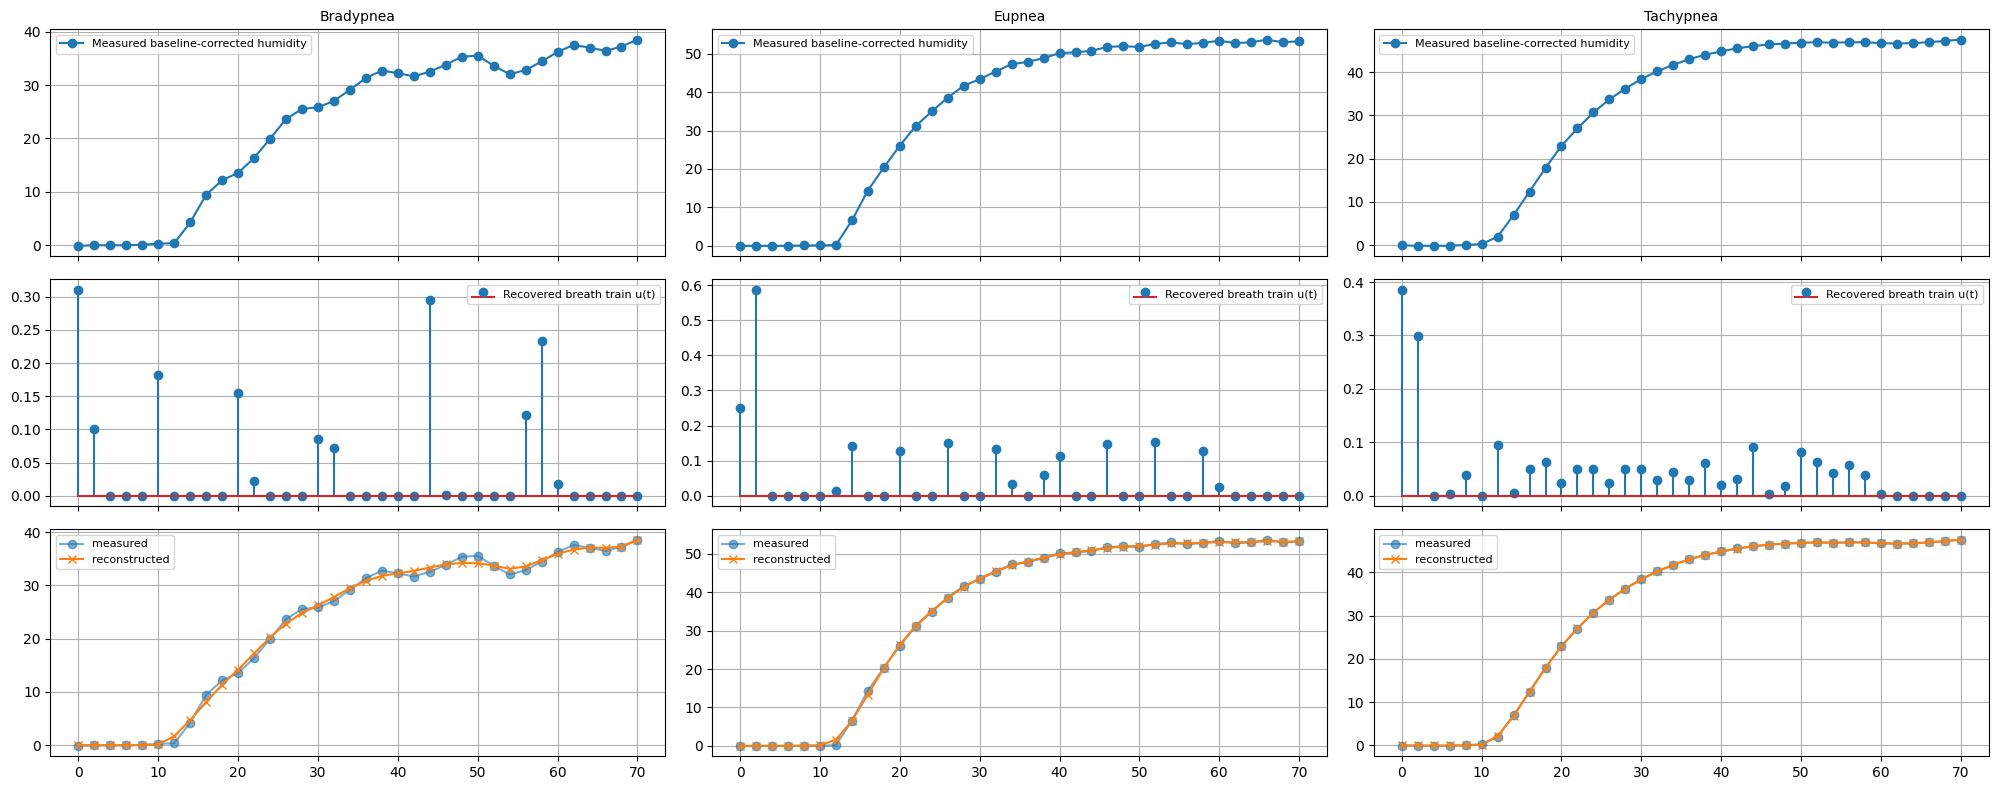

In [4]:
# deconvolution
def cir_kernel(time_grid, A, D, v, t_shift, tau_s):
    cir = advection_diffusion(time_grid, A, D, v, t_shift)
    dt = time_grid[1] - time_grid[0]
    t_kernel = np.arange(0, time_grid[-1] + dt, dt)
    s = sensor_kernel(t_kernel, tau_s)
    kernel = np.convolve(cir, s, mode='full')[:len(time_grid)] * dt
    return kernel

def deconvolve_nnls(y, h, N, lam=0.1):
    # build conv matrix
    H = np.zeros((N, N))
    for i in range(N):
        for j in range(i + 1):
            if i - j < len(h):
                H[i, j] = h[i - j]

    # solve nnls with tikhonov regularization
    H_aug = np.vstack([H, np.sqrt(lam) * np.eye(N)])
    y_aug = np.concatenate([y, np.zeros(N)])
    u, residual = nnls(H_aug, y_aug)
    return u

# load data
df = load_dataset('dataset')
df = df[df['region'] == region].reset_index(drop=True)
df_train, df_val, df_test = split_dataset(df, random_state=SEED)

# define cir param
params_mouth = mean_then_fit['mouth']["humidity_params"]
time = np.arange(36)*2.0

cir_kernel_mouth = cir_kernel(time, *params_mouth, tau_s=15.0)
fig, axes = plt.subplots(3, 3, figsize=(20, 8), sharex=True)

for i, cls in enumerate(CLASS_TO_IDX.keys()):
    # get sample
    sample = df[df['class'] == cls].iloc[0]
    humidity = sample['humidity']
    temperature = sample['temperature']

    # preprocess
    humidity_baseline_corrected, _ = preprocess_cir(humidity, temperature)

    # deconvolve
    signal_recovered = deconvolve_nnls(humidity_baseline_corrected, cir_kernel_mouth, N=36, lam=0.5)

    # plot
    axes[0][i].plot(time, humidity_baseline_corrected, 'o-', label='Measured baseline-corrected humidity')
    axes[0][i].grid()
    axes[0][i].legend(loc='upper left')
    axes[0][i].set_title(f'{cls.capitalize()}')
    
    axes[1][i].stem(time, signal_recovered, label='Recovered breath train u(t)')
    axes[1][i].grid()
    axes[1][i].legend(loc='upper right')
    
    y_reconstructed = np.convolve(signal_recovered, cir_kernel_mouth)[:36]
    axes[2][i].plot(time, humidity_baseline_corrected, 'o-', label='measured', alpha=0.6)
    axes[2][i].plot(time, y_reconstructed, 'x-', label='reconstructed')
    axes[2][i].legend()
    axes[2][i].grid()

plt.tight_layout()
plt.show()

In [ ]:
# create pde for the same result
def pde():
    pass